In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from skimage.exposure import match_histograms
from PIL import Image

In [ ]:
def show_gray(img, title):
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

def show_rgb(img, title):
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()

def show_hist(img, title):
    plt.figure(figsize=(6,4))
    plt.hist(img.ravel(), bins=256, range=(0,256))
    plt.title(title)
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.show()

# Question 1: Logarithmic and Power-Law Transformation

**Read image**

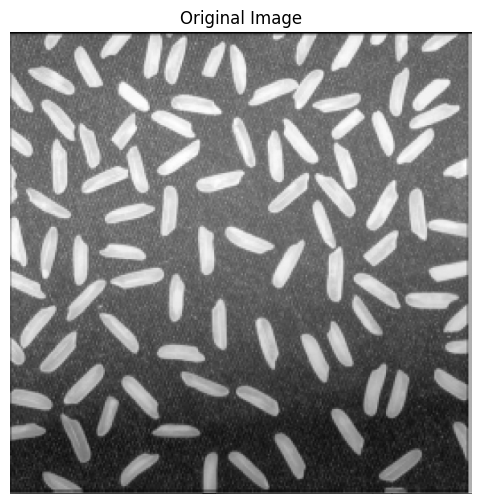

In [ ]:
rice = cv2.imread("image1.png", cv2.IMREAD_GRAYSCALE)

show_gray(rice, "Original Image")

**Logarithmic Transformation**

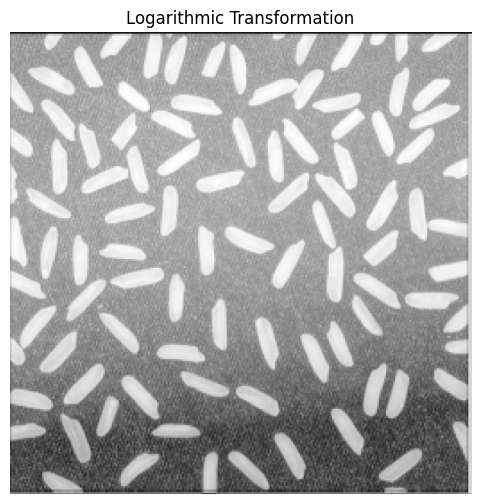

In [ ]:
c = 255 / np.log(1 + np.max(rice))

log_transformed = c * np.log(1 + rice)
log_transformed = np.array(log_transformed, dtype=np.uint8)

show_gray(log_transformed, "Logarithmic Transformation")

**Power-Law Transformation**

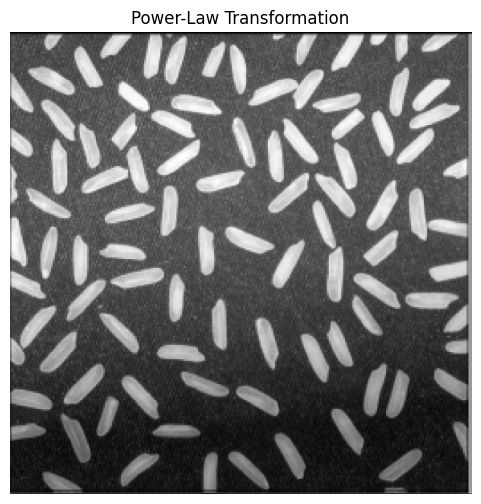

In [ ]:
gamma = 1.5

normalized = rice / 255.0
power_law = np.power(normalized, gamma)
power_law = np.uint8(power_law * 255)

show_gray(power_law, "Power-Law Transformation")

**Compare outputs**

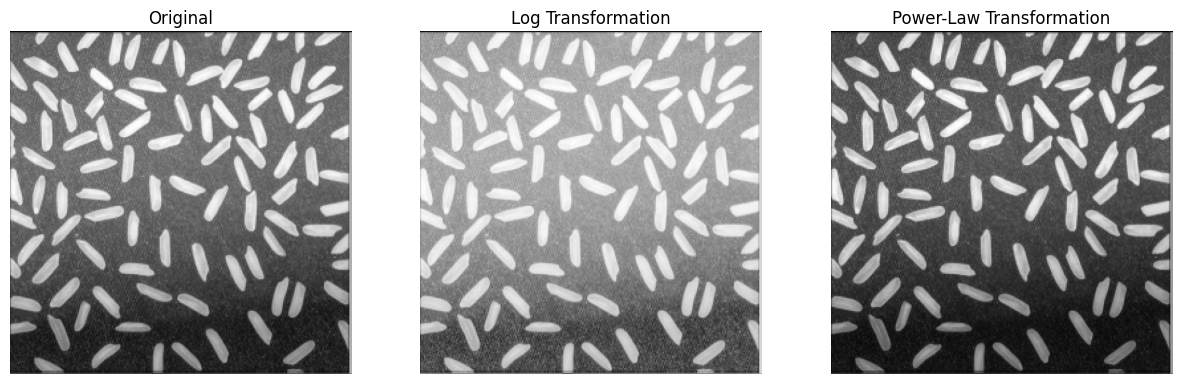

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(rice, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(log_transformed, cmap='gray')
plt.title("Log Transformation")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(power_law, cmap='gray')
plt.title("Power-Law Transformation")
plt.axis("off")

plt.show()

# Question 2: Histogram Equalization

**Read CT scan image**

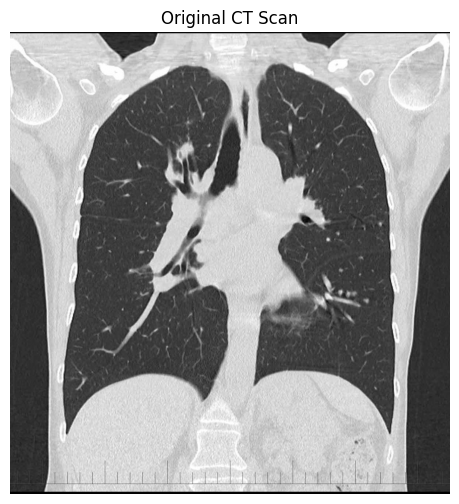

In [ ]:
ct_scan = cv2.imread("image3.jpg", cv2.IMREAD_GRAYSCALE)

show_gray(ct_scan, "Original CT Scan")

**Apply histogram equalization**

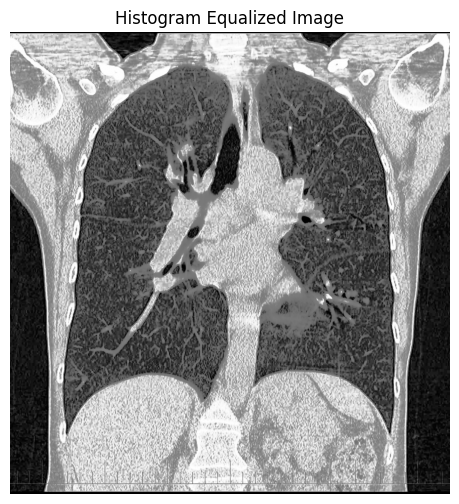

In [ ]:
equalized_ct = cv2.equalizeHist(ct_scan)

show_gray(equalized_ct, "Histogram Equalized Image")

**Show original and equalized images**

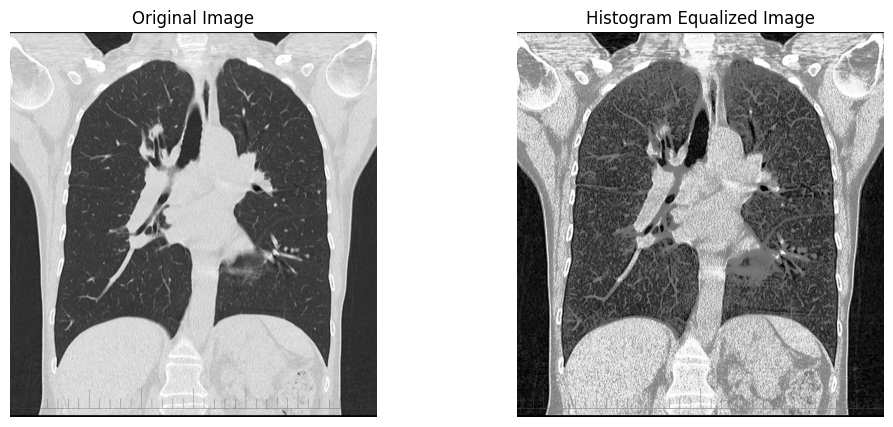

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(ct_scan, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(equalized_ct, cmap='gray')
plt.title("Histogram Equalized Image")
plt.axis("off")

plt.show()

**Show histograms of input and output**

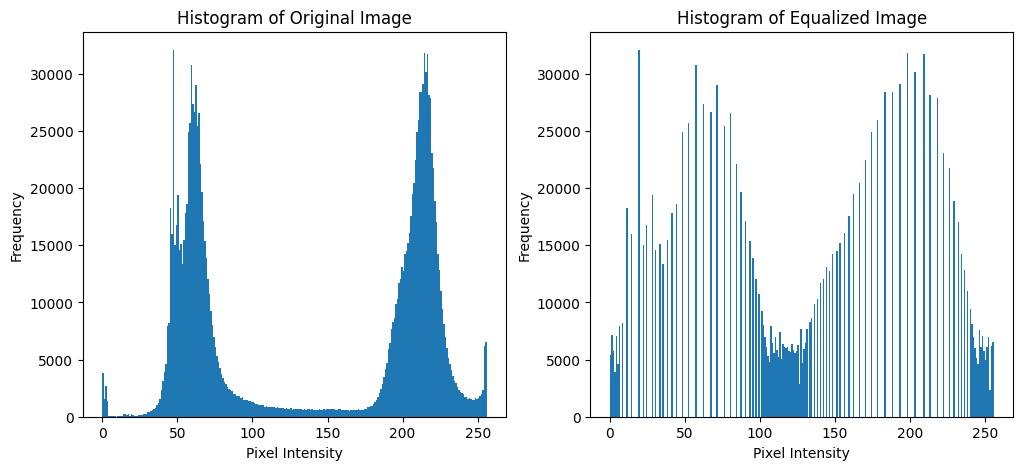

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(ct_scan.ravel(), bins=256, range=(0,256))
plt.title("Histogram of Original Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(equalized_ct.ravel(), bins=256, range=(0,256))
plt.title("Histogram of Equalized Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

# Question 3: Histogram Matching

**Read original and reference images**

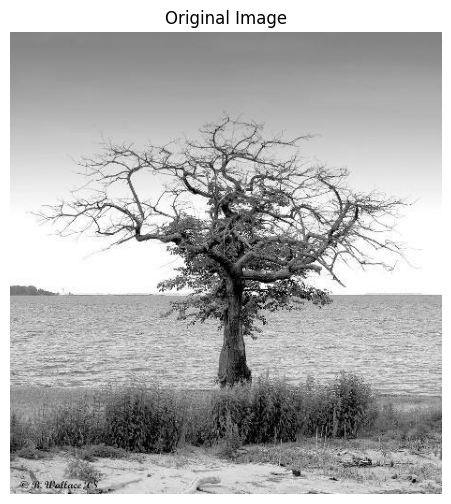

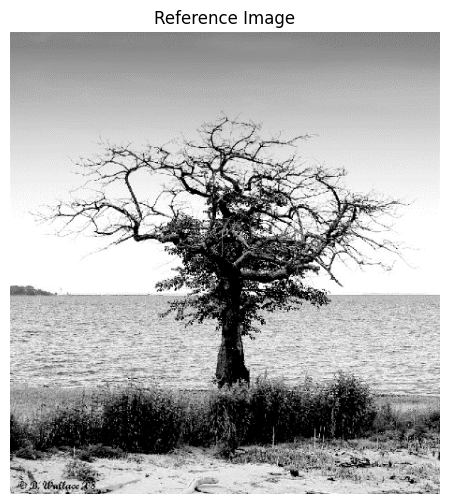

In [ ]:
original_tree = cv2.imread("image2.jpg", cv2.IMREAD_GRAYSCALE)
reference_tree = cv2.imread("image5.png", cv2.IMREAD_GRAYSCALE)

show_gray(original_tree, "Original Image")
show_gray(reference_tree, "Reference Image")

**Apply histogram matching**

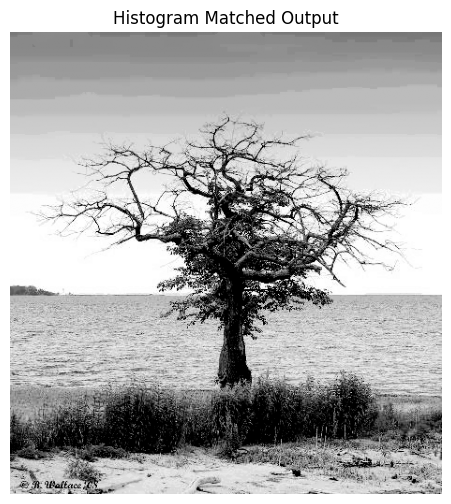

In [ ]:
matched_tree = match_histograms(original_tree, reference_tree)
matched_tree = np.uint8(matched_tree)

show_gray(matched_tree, "Histogram Matched Output")

**Show original, reference, and output images**

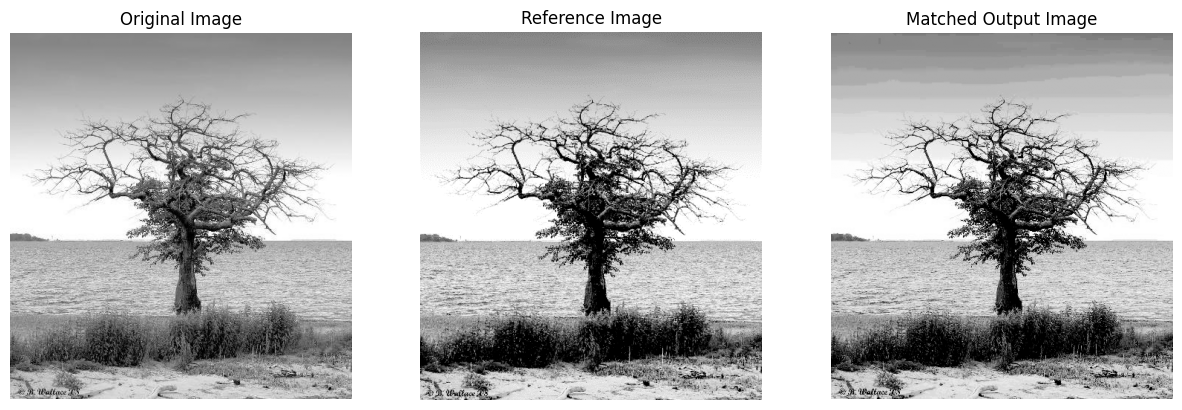

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(original_tree, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(reference_tree, cmap='gray')
plt.title("Reference Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(matched_tree, cmap='gray')
plt.title("Matched Output Image")
plt.axis("off")

plt.show()

**Show histograms of original, reference, and output**

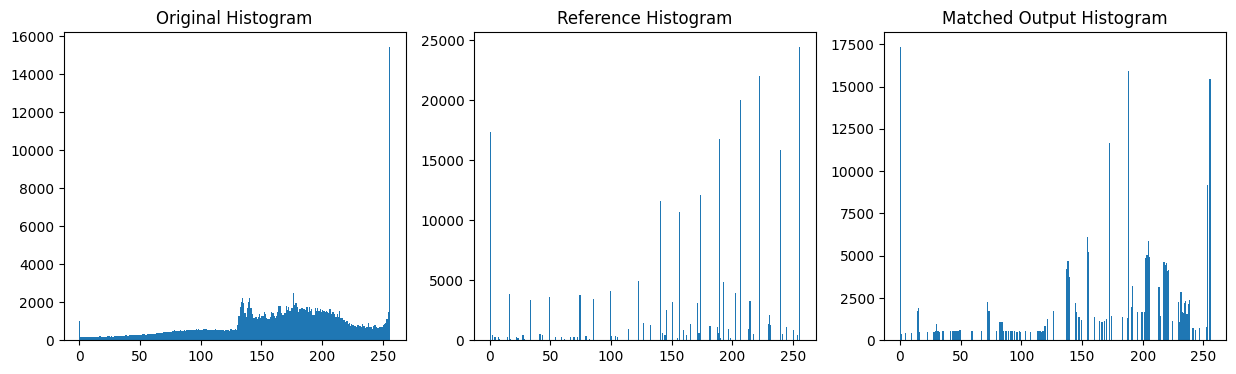

In [ ]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(original_tree.ravel(), bins=256, range=(0,256))
plt.title("Original Histogram")

plt.subplot(1,3,2)
plt.hist(reference_tree.ravel(), bins=256, range=(0,256))
plt.title("Reference Histogram")

plt.subplot(1,3,3)
plt.hist(matched_tree.ravel(), bins=256, range=(0,256))
plt.title("Matched Output Histogram")

plt.show()

# Question 4: Matrix, Pixel Value, Image Size, Image Information

**Read image**

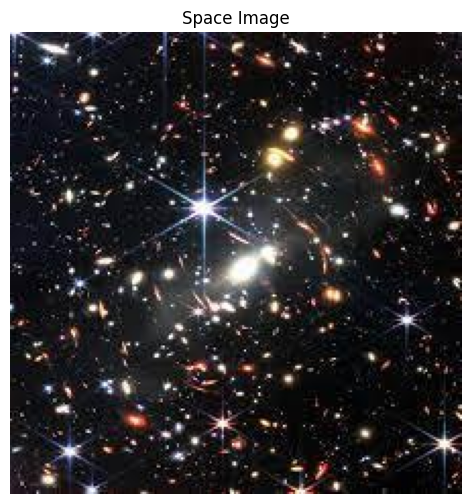

In [ ]:
space = cv2.imread("image4.jpg")

space_rgb = cv2.cvtColor(space, cv2.COLOR_BGR2RGB)

show_rgb(space_rgb, "Space Image")

**Show matrix form of image**

In [ ]:
print("Matrix form of the image:")
print(space_rgb)

Matrix form of the image:
[[[225 229 255]
  [241 245 255]
  [247 248 255]
  ...
  [ 23  21  26]
  [ 43  42  47]
  [ 45  44  49]]

 [[111 115 142]
  [202 206 233]
  [209 213 240]
  ...
  [  7   5  10]
  [ 33  32  37]
  [ 43  42  47]]

 [[ 47  53  79]
  [123 129 155]
  [189 193 220]
  ...
  [  4   2   7]
  [ 23  22  27]
  [ 28  27  32]]

 ...

 [[ 46  33  43]
  [ 38  25  35]
  [ 34  21  31]
  ...
  [ 15  11   8]
  [ 22  18  15]
  [ 29  25  22]]

 [[ 46  33  43]
  [ 38  25  35]
  [ 34  21  31]
  ...
  [  6   5   1]
  [ 12  11   7]
  [ 17  16  12]]

 [[ 46  33  43]
  [ 38  25  35]
  [ 34  21  31]
  ...
  [  2   1   0]
  [  5   4   0]
  [  8   7   3]]]


**Find pixel value at (10, 78)**

In [ ]:
# In image processing, pixel coordinate is usually row, column
pixel_value = space_rgb[10, 78]

print("Pixel value at position (10, 78):", pixel_value)

Pixel value at position (10, 78): [20 19 25]


**Show size of image**

In [ ]:
height, width, channels = space_rgb.shape

print("Height:", height)
print("Width:", width)
print("Channels:", channels)
print("Image size:", space_rgb.shape)

Height: 227
Width: 222
Channels: 3
Image size: (227, 222, 3)


**Show all image information**

In [ ]:
print("Image Information")
print("------------------")
print("Image Type:", type(space_rgb))
print("Image Shape:", space_rgb.shape)
print("Image Height:", space_rgb.shape[0])
print("Image Width:", space_rgb.shape[1])
print("Number of Channels:", space_rgb.shape[2])
print("Data Type:", space_rgb.dtype)
print("Minimum Pixel Value:", space_rgb.min())
print("Maximum Pixel Value:", space_rgb.max())
print("Total Number of Pixels:", space_rgb.shape[0] * space_rgb.shape[1])

Image Information
------------------
Image Type: <class 'numpy.ndarray'>
Image Shape: (227, 222, 3)
Image Height: 227
Image Width: 222
Number of Channels: 3
Data Type: uint8
Minimum Pixel Value: 0
Maximum Pixel Value: 255
Total Number of Pixels: 50394
